In [1]:
##https://stackabuse.com/hierarchical-clustering-with-python-and-scikit-learn/
##libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster  # Import the fcluster function
from scipy.cluster.hierarchy import dendrogram
from scipy.spatial import distance
import sklearn.metrics as sm 

In [2]:
#dataframe
gtsB_4c = pd.read_csv('data_clusterfinal_2PCA_3Clusters_4foldcodons_gtsbfinal_only_quanti_mainf.csv')
print(gtsB_4c.shape)
print(gtsB_4c.head())
print(gtsB_4c.isnull().sum())
print(gtsB_4c.shape)
print(gtsB_4c.info())



(100, 8)
   substitution_rate  transitions  transversions  \
0         133.496364    73.337273      60.159091   
1         109.740909    53.382727      56.358182   
2         228.418182   170.226364      58.191818   
3         349.265454   168.886364     180.379091   
4         150.549091    67.159091      83.390000   

   T-ending_codon_relative_probability  A-ending_codon_relative_probability  \
0                             0.339764                             0.096387   
1                             0.254790                             0.220345   
2                             0.100398                             0.386440   
3                             0.236473                             0.133139   
4                             0.249626                             0.141760   

   G-ending_codon_relative_probability  C-ending_codon_relative_probability  \
0                             0.236173                             0.327677   
1                             0.321369       

In [3]:
print(gtsB_4c.head())

   substitution_rate  transitions  transversions  \
0         133.496364    73.337273      60.159091   
1         109.740909    53.382727      56.358182   
2         228.418182   170.226364      58.191818   
3         349.265454   168.886364     180.379091   
4         150.549091    67.159091      83.390000   

   T-ending_codon_relative_probability  A-ending_codon_relative_probability  \
0                             0.339764                             0.096387   
1                             0.254790                             0.220345   
2                             0.100398                             0.386440   
3                             0.236473                             0.133139   
4                             0.249626                             0.141760   

   G-ending_codon_relative_probability  C-ending_codon_relative_probability  \
0                             0.236173                             0.327677   
1                             0.321369                

In [21]:
gtsB_4cf = gtsB_4c.drop(['nucleotide_position'], axis=1)

In [22]:
X = gtsB_4cf.values

In [23]:
if X.shape[0] == 0:
    print("Error: No rows in the dataframe after filtering and selecting.")
else:
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  #X corresponds to the data matrix

In [24]:
#PCA
pca = PCA(n_components=2) ##I also tested 5pc
principal_components = pca.fit_transform(X_scaled)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2']) ##'PC3', 'PC4','PC5'])

In [25]:
#Create a dataframe containing explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
components_df = pd.DataFrame({'Principal Component': ['PC1', 'PC2'], #,'PC3', 'PC4','PC5'],
                              'Explained Variance Ratio': explained_variance_ratio})

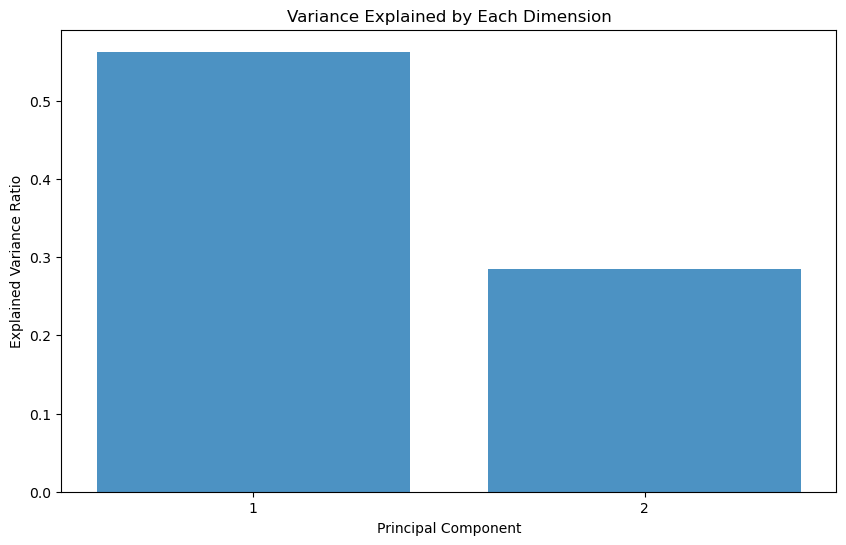

In [26]:
#Calculate explained variance for each component
explained_variance = pca.explained_variance_ratio_

# Plot bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, align='center', alpha=0.8)
plt.title('Variance Explained by Each Dimension')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance) + 1))
#plt.grid(axis='y')

plt.savefig('gtsB_4fold_explained_variancegraph_2pc.png', dpi=800)


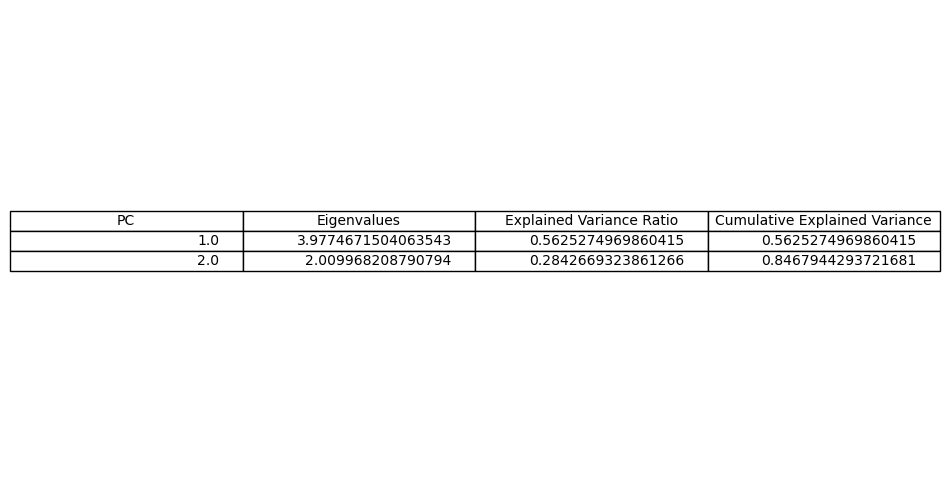

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
# Create DataFrame
eigen_df = pd.DataFrame({
    'PC': range(1, pca.n_components_ + 1),
    'Eigenvalues': pca.explained_variance_,
    'Explained Variance Ratio': pca.explained_variance_ratio_,
    'Cumulative Explained Variance': np.cumsum(pca.explained_variance_ratio_)
})

#Convert DataFrame to a table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=eigen_df.values, colLabels=eigen_df.columns, loc='center')

#formating table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

#Save the figure as PNG
plt.savefig('eigenvalues_gtsB_4fold_finaltable.png', bbox_inches='tight', pad_inches=0.05)
plt.show()

In [11]:
# Eigenvalues
eigenvalues = pca.explained_variance_
print("eigenvalues:")
print(eigenvalues)

eigenvalues:
[3.97746715 2.00996821]


In [27]:
#hierarchical clustering on the principal components with Ward linkage
n_clusters = 3
clustering = AgglomerativeClustering(n_clusters=n_clusters, metric ='euclidean', linkage='ward')  # Set the number of clusters and linkage method
cluster_labels = clustering.fit_predict(principal_df)




In [28]:
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
#Create a DataFrame with the cluster labels
cluster_df = pd.DataFrame({'Individual': range(len(cluster_labels)),
                           'Cluster': cluster_labels,
                          'nucleotide_position': gtsB_4c['nucleotide_position'],
                           'substitution_rate': gtsB_4c['substitution_rate']
                          })

# Display the DataFrame
print(cluster_df)

csv_clusters=cluster_df


csv_file_path = 'gtsB_cluster_positions_4-fold-sites_3clusters_2PCAf.csv'
csv_clusters.to_csv(csv_file_path, index=False)

    Individual  Cluster  nucleotide_position  substitution_rate
0            0        1                   12         133.496364
1            1        0                   18         109.740909
2            2        0                   72         228.418182
3            3        0                   96         349.265454
4            4        1                  102         150.549091
..         ...      ...                  ...                ...
95          95        1                  384          57.067273
96          96        2                  390         410.141818
97          97        2                  735         431.123636
98          98        1                  792         236.341818
99          99        1                  894          20.142727

[100 rows x 4 columns]


In [29]:
loadings = pca.components_

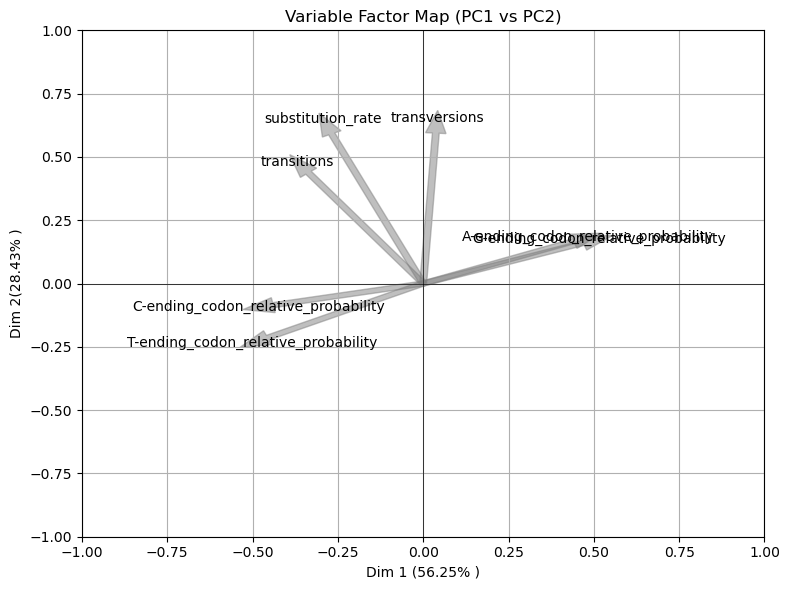

In [30]:
##Variable factor maps PC1-PC2
# Variable names
variable_names = ['substitution_rate',  'transitions', 'transversions','T-ending_codon_relative_probability', 'A-ending_codon_relative_probability', 'G-ending_codon_relative_probability', 'C-ending_codon_relative_probability']

# Plot the variable factor map
plt.figure(figsize=(8, 6))
for i in range(loadings.shape[1]):  # Iterate over variables
    plt.arrow(0, 0, loadings[0, i], loadings[1, i], color='gray', alpha=0.5, width=0.02)  # Plot arrow for PC1 and PC2
    plt.text(loadings[0, i] * 1.1, loadings[1, i] * 1.1, variable_names[i], color='black', ha='center', va='center')  # Label variable
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(f'Dim 1 ({explained_variance_ratio[0]*100:.2f}% )')
plt.ylabel(f'Dim 2({explained_variance_ratio[1]*100:.2f}% )')
plt.title('Variable Factor Map (PC1 vs PC2)')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()



# Save the plot to PNG
plt.savefig('pca_components_gtsb_4foldf.png', dpi=600)
plt.show()  


In [31]:
# Create a dataframe containing explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
components_df = pd.DataFrame({'Principal Component': ['PC1', 'PC2'],
                              'Explained Variance Ratio': explained_variance_ratio})



In [32]:
# Add cluster labels to the dataframe
principal_df['cluster'] = cluster_labels

In [33]:
# labeling using nucleotide position
variable_values = gtsB_4c['nucleotide_position'].values


C:\Users\user\AppData\Local\Temp\ipykernel_32896\885188305.py:13: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  sns.scatterplot(x='PC1', y='PC2', data=principal_df, hue=cluster_labels, palette=custom_order, legend='full')


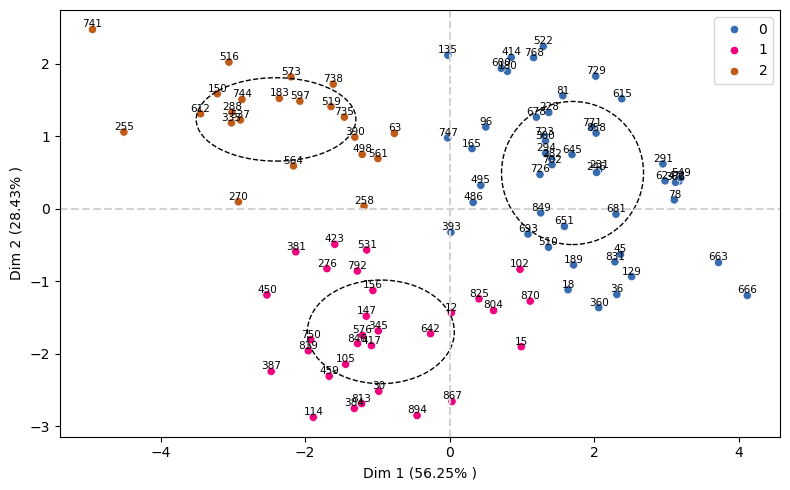

In [34]:

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


paired_palette = sns.color_palette("Accent", 12)


custom_order = [paired_palette[i] for i in [4, 5, 6, 7, 1, 2, 3, 0, 8]]

plt.figure(figsize=(8, 5))
sns.scatterplot(x='PC1', y='PC2', data=principal_df, hue=cluster_labels, palette=custom_order, legend='full')


plt.title('')
plt.xlabel(f'Dim 1 ({explained_variance_ratio[0]*100:.2f}% )')
plt.ylabel(f'Dim 2 ({explained_variance_ratio[1]*100:.2f}% )')
# Add a dashed line at (0, 0)
plt.axhline(0, color='LightGray', linestyle='--')
plt.axvline(0, color='LightGray', linestyle='--')


# Add ellipses around each cluster of dots
for cluster in principal_df['cluster'].unique():
    cluster_data = principal_df[principal_df['cluster'] == cluster]
    ellipse = Ellipse(xy=(cluster_data['PC1'].mean(), cluster_data['PC2'].mean()), width=cluster_data['PC1'].std() * 2, height=cluster_data['PC2'].std() * 2, edgecolor='black', linestyle='--', fill=False)
    plt.gca().add_patch(ellipse)

# Add labels to each point
for i, txt in enumerate(variable_values):
    plt.text(principal_components[i, 0], principal_components[i, 1], txt, fontsize=7.5, ha='center', va='bottom')


plt.tight_layout()
# Save the plot to PNG
plt.savefig('gtsB_4fold_3groups_2PCAfinal2t.png', dpi=600)
plt.show()  


In [36]:
# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)  # X is your data matrix



In [35]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)  # X is your data matrix



In [36]:
# Perform hierarchical clustering on principal components with Ward method
Z = linkage(principal_components, method='ward')



In [37]:

principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])



In [38]:
cluster_labels = clustering.fit_predict(principal_df)



In [40]:
sites_labels =gtsB_4c['nucleotide_position']


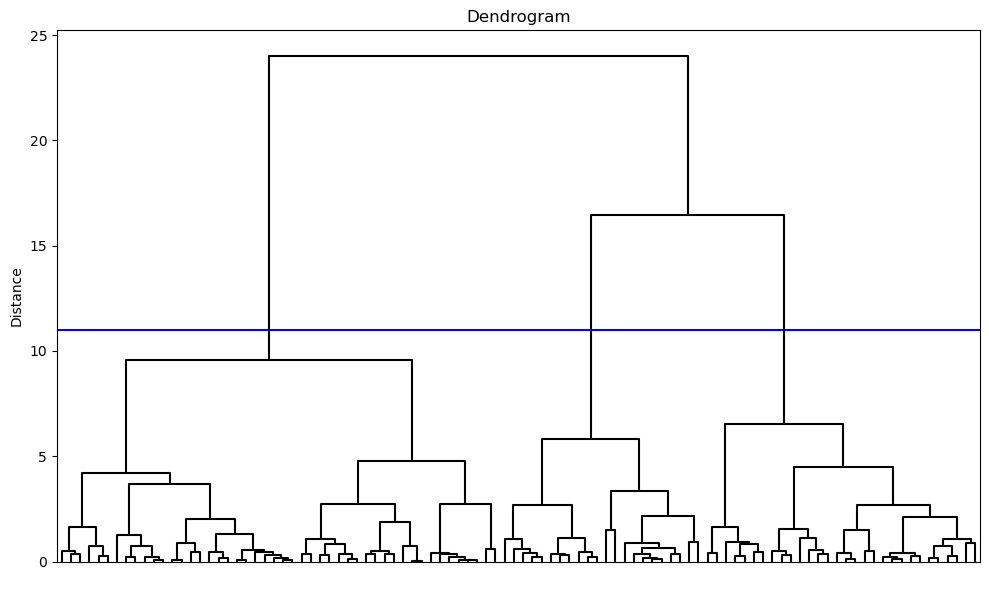

In [41]:

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(10, 6))

dendrogram1 = dendrogram(linkage(principal_components, method='ward'), show_contracted=False, link_color_func=lambda x: 'black')



plt.title('Dendrogram')
plt.ylabel('Distance')

plt.axhline (y=11, color = 'b', linestyle = '-')

# Set x-axis tick parameters to white
plt.xticks(color='white')  

plt.tight_layout()

# Save the plot to PNG
plt.savefig('dendrogram_gtsb_4fold_3groups_2PCAfinal.png', dpi=600)
plt.show()  


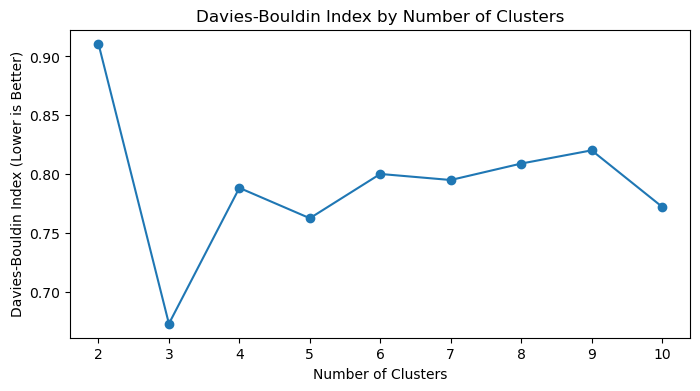

In [42]:
##davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score

# Range of cluster numbers to try
range_n_clusters = range(2, 11)

# List to store Davies-Bouldin Index scores
db_scores = []

for n_clusters in range_n_clusters:
    # Initialize AgglomerativeClustering with Ward linkage
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = clusterer.fit_predict(principal_df)  
    
    # Compute the Davies-Bouldin Index
    db_score = davies_bouldin_score(principal_df, cluster_labels)
    db_scores.append(db_score)

# Plot the Davies-Bouldin Index scores
plt.figure(figsize=(8, 4))
plt.plot(range_n_clusters, db_scores, marker='o')

# Improve x-axis 
plt.xticks(range_n_clusters)

# Add title and labels
plt.title('Davies-Bouldin Index by Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index (Lower is Better)')

# Saving the plot
plt.savefig('davies_bouldin_score_gtsB_4fold.png', dpi=600)
plt.show()  
